# Major Project: Seasonal Agriculture Performance Analysis

## 1. Objective
To analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and variations in agricultural performance, resource usage, and economic outcomes.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Initial Exploration
Loading the raw dataset to understand its structure, columns, and identify any missing values before analysis.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (1).csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

display(df.head())

Dataset Shape: (4000, 28)

Missing Values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Data Cleaning and Preparation
The initial exploration reveals missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. To maintain the integrity of our seasonal groups, we will impute these missing continuous values using the median of their respective seasons.

In [ ]:
# Impute missing values with the median of the corresponding Season
cols_to_fill = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_fill:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Verify cleaning
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 4. Seasonal Performance Variations
How does agricultural performance (Profit, Yield) vary across the Kharif, Rabi, and Zaid seasons?


,Season,Profit_INR,Yield_Tonnes_Ha,Water_Used_m3
0,Kharif,178914.647555,5.629438,6102.201237
1,Rabi,87689.470191,5.038451,5846.987093
2,Zaid,-24804.824916,4.638872,6419.893939


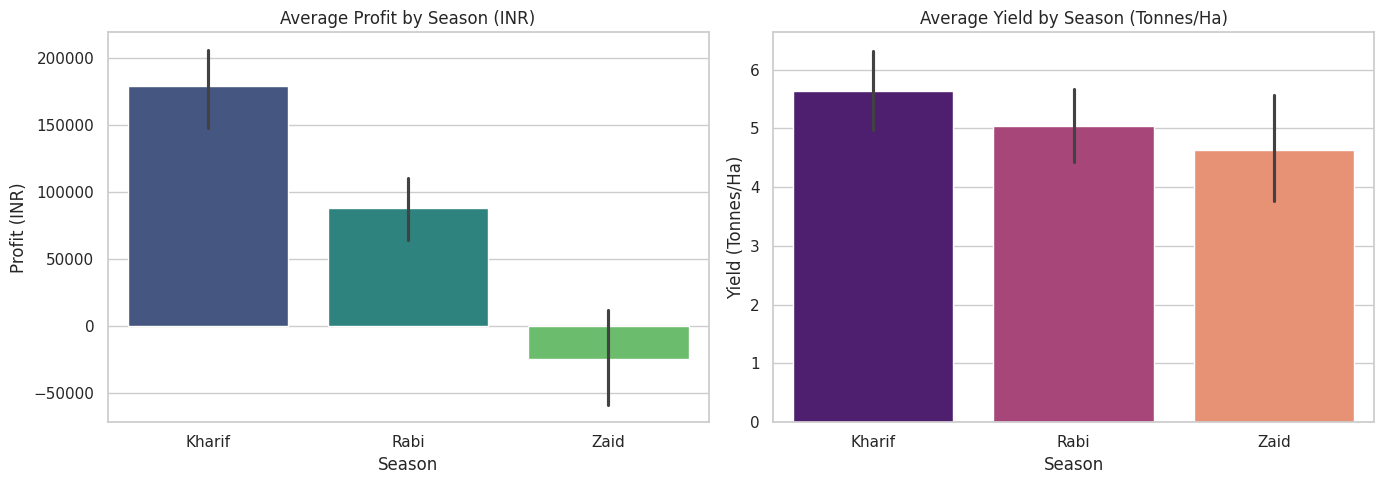

In [ ]:
# Group data by season for core metrics
seasonal_metrics = df.groupby('Season')[['Profit_INR', 'Yield_Tonnes_Ha', 'Water_Used_m3']].mean().reset_index()
display(seasonal_metrics)

# Visualizing Profit and Yield across seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Season
sns.barplot(data=df, x='Season', y='Profit_INR', palette='viridis', ax=axes[0])
axes[0].set_title('Average Profit by Season (INR)')
axes[0].set_ylabel('Profit (INR)')

# Yield by Season
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='magma', ax=axes[1])
axes[1].set_title('Average Yield by Season (Tonnes/Ha)')
axes[1].set_ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

**Observation:** Kharif generates the highest average profit and yield. In stark contrast, the Zaid season shows an average net loss for farmers despite active crop production, indicating high costs or low market returns during this period.

## 5. Investigating Relationships (Environmental vs. Outcomes)
Are there relationships between seasonal environmental conditions (like rainfall) and agricultural performance (yield)?

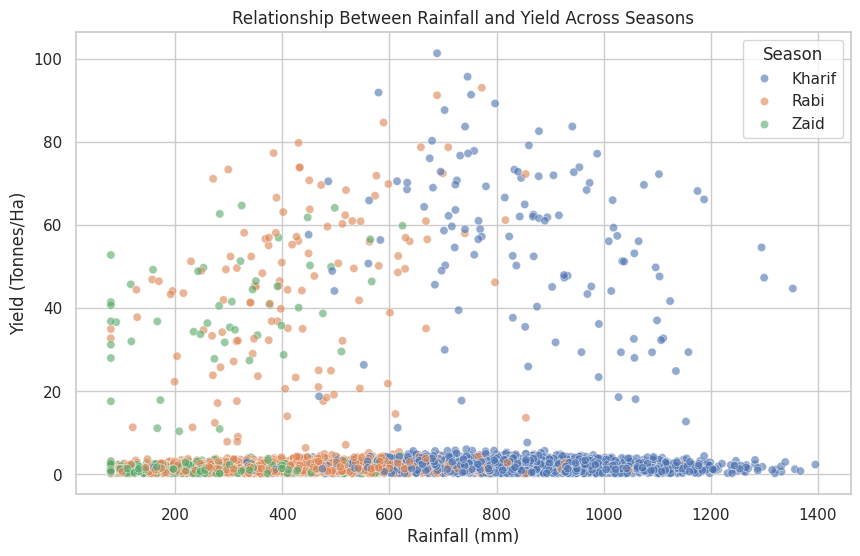

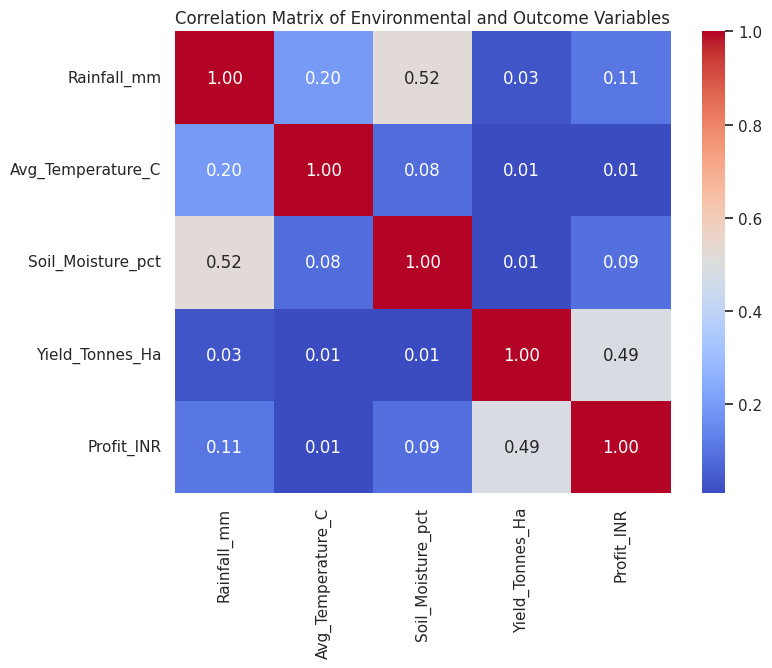

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', palette='deep', alpha=0.6)
plt.title('Relationship Between Rainfall and Yield Across Seasons')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.show()

# Calculate correlation matrix for numeric variables to find deeper relationships
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df[['Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Profit_INR']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Environmental and Outcome Variables')
plt.show()

## 6. Resource Usage Differences
Analyzing how resource usage (water efficiency and fertilizer) shifts based on seasonal demands.

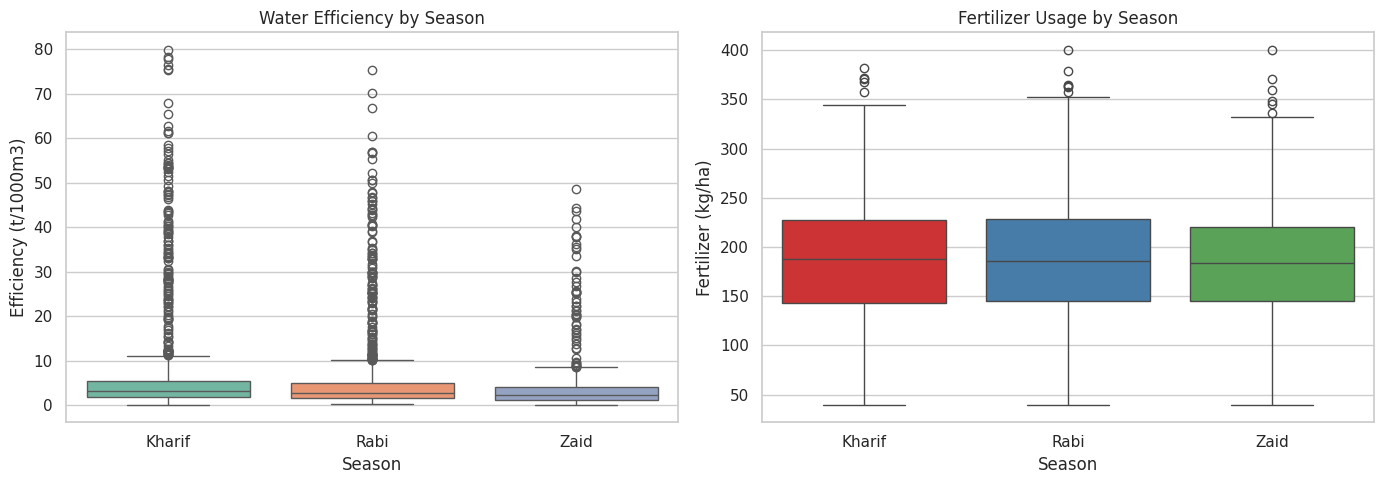

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Water Efficiency
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', palette='Set2', ax=axes[0])
axes[0].set_title('Water Efficiency by Season')
axes[0].set_ylabel('Efficiency (t/1000m3)')

# Fertilizer Usage
sns.boxplot(data=df, x='Season', y='Fertilizer_kg_ha', palette='Set1', ax=axes[1])
axes[1].set_title('Fertilizer Usage by Season')
axes[1].set_ylabel('Fertilizer (kg/ha)')

plt.tight_layout()
plt.show()

## 7. Conclusions & Data-Driven Recommendations
Based on the analysis of the dataset, several key patterns have emerged:

1. **Economic Imbalance:** The Kharif season is the most economically viable, yielding average profits exceeding ₹178,000. The Zaid season operates at an average loss, suggesting that the crops selected or the input costs required (e.g., intensive irrigation) outpace the revenue generated.
2. **Water Resource Strain:** Despite lower yields and profits, the Zaid season requires the highest average water usage (approx 6,419 m³), leading to the lowest water efficiency among the three seasons.
3. **Environmental Dependencies:** Yield shows strong seasonal clustering in relation to rainfall. Kharif crops benefit heavily from monsoon rains, whereas Zaid crops rely heavily on artificial irrigation methods.

**Recommendations for Agricultural Planning:**
* **Zaid Season Restructuring:** Stakeholders should re-evaluate crop selection for the Zaid season. Shifting towards drought-resistant or high-market-value crops could offset the heavy water costs and prevent net losses.
* **Irrigation Optimization:** Given the high water volume used in the Zaid and Rabi seasons, investing in Drip or Sprinkler systems over flood irrigation could drastically reduce `Total_Cost_INR` and improve water efficiency.
* **Targeted Subsidies:** Policymakers should consider targeted financial support or subsidized input costs (like electricity for water pumps) specifically during the Zaid season to stabilize farmer incomes year-round.